# Adzuna Sector Job Pipeline

sector-level job searches designed for the workflow:

**8 sector keywords → Adzuna search → full raw payload storage → field flattening → sector hiring / noise summaries**

Compared with a minimal jobs extractor, this version keeps:
- the full raw JSON payload for each vacancy
- flattened API fields from the Adzuna response
- optional noise / quality signals that can be used later in scoring

In [1]:
import os
import json
import time
import sqlite3
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm.auto import tqdm


In [2]:
# =========================================================
# Configuration
# =========================================================
INPUT_PATH = Path("../output/UKcompanies_8_sectors_cleaned.csv")

OUTPUT_DIR = Path("../output/adzuna_sector_fullfield_output")
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_JOBS_CSV = OUTPUT_DIR / "adzuna_sector_jobs_raw_full.csv"
SECTOR_SUMMARY_CSV = OUTPUT_DIR / "adzuna_sector_hiring_summary.csv"
CACHE_DB = OUTPUT_DIR / "adzuna_sector_cache.sqlite"

# You can set these in your environment instead of hardcoding them.
# Example:
#   export ADZUNA_APP_ID="..."
#   export ADZUNA_APP_KEY="..."
ADZUNA_APP_ID = os.getenv("ADZUNA_APP_ID", "9d40f51d").strip()
ADZUNA_APP_KEY = os.getenv("ADZUNA_APP_KEY", "6a151e5f23976ded9a47ce1cf059df04").strip()

if not ADZUNA_APP_ID or not ADZUNA_APP_KEY:
    raise ValueError("Please set ADZUNA_APP_ID and ADZUNA_APP_KEY in your environment variables.")

BASE_URL = "https://api.adzuna.com/v1/api/jobs"
COUNTRY = "gb"
WHERE_VALUE = "uk"

RESULTS_PER_PAGE = 50
MAX_PAGES_PER_QUERY = 2
REQUEST_SLEEP_SECONDS = 0.4

# Run a smaller sample first, then set this to None or a larger number.
SAMPLE_SIZE = 50

# Sector keyword map used for sector-level hiring estimation.
SECTOR_QUERY_MAP = {
    "Manufacturing": [
        "manufacturing",
        "production",
        "factory",
        "process engineer",
        "maintenance engineer",
    ],
    "Healthcare": [
        "healthcare",
        "nurse",
        "medical",
        "care worker",
        "clinical",
    ],
    "Technology, legal & professional": [
        "software engineer",
        "developer",
        "data analyst",
        "consultant",
        "solicitor",
    ],
    "Agriculture": [
        "agriculture",
        "farm",
        "farmer",
        "horticulture",
        "agronomist",
    ],
    "Real Estate": [
        "property",
        "estate agent",
        "lettings",
        "property manager",
        "surveying",
    ],
    "Wholesale & Retail": [
        "retail",
        "sales assistant",
        "store manager",
        "wholesale",
        "merchandiser",
    ],
    "Public sector, education & charities": [
        "teacher",
        "lecturer",
        "council",
        "charity",
        "fundraising",
    ],
    "Fast growth & emerging sector": [
        "product manager",
        "data scientist",
        "machine learning",
        "growth marketing",
        "startup",
    ],
}

TARGET_SECTORS = list(SECTOR_QUERY_MAP.keys())


In [3]:
# =========================================================
# Load Companies House company data
# =========================================================
df = pd.read_csv(INPUT_PATH, dtype=str)

required_cols = {"CompanyNumber", "CompanyName", "primary_sector"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Input file missing required columns: {sorted(missing)}")

df["primary_sector"] = df["primary_sector"].astype("string").str.strip()

focus_companies = df[df["primary_sector"].isin(TARGET_SECTORS)].copy()
focus_companies = (
    focus_companies[["CompanyNumber", "CompanyName", "primary_sector"]]
    .drop_duplicates()
    .head(SAMPLE_SIZE)
    .copy()
)

focus_companies.shape


(50, 3)

In [4]:
# =========================================================
# Requests session with retry support
# =========================================================
def make_session() -> requests.Session:
    session = requests.Session()
    retry = Retry(
        total=5,
        read=5,
        connect=5,
        backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session

session = make_session()


In [5]:
# =========================================================
# SQLite cache helpers
# =========================================================
def init_cache():
    conn = sqlite3.connect(CACHE_DB)
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS sector_cache (
            cache_key TEXT PRIMARY KEY,
            response_json TEXT,
            fetched_at TEXT
        )
    """)
    conn.commit()
    conn.close()

def sector_cache_key(sector_name: str, query: str, where: Optional[str], page: int) -> str:
    return f"{sector_name}|{query.lower().strip()}|{(where or '').lower().strip()}|{page}"

def cache_get(key: str) -> Optional[dict]:
    conn = sqlite3.connect(CACHE_DB)
    cur = conn.cursor()
    cur.execute("SELECT response_json FROM sector_cache WHERE cache_key = ?", (key,))
    row = cur.fetchone()
    conn.close()
    if not row:
        return None
    try:
        return json.loads(row[0])
    except Exception:
        return None

def cache_put(key: str, response: dict):
    conn = sqlite3.connect(CACHE_DB)
    cur = conn.cursor()
    cur.execute("""
        INSERT OR REPLACE INTO sector_cache (cache_key, response_json, fetched_at)
        VALUES (?, ?, datetime('now'))
    """, (key, json.dumps(response, ensure_ascii=False)))
    conn.commit()
    conn.close()

init_cache()
print("Cache initialized.")


Cache initialized.


In [6]:
# =========================================================
# Adzuna API request
# =========================================================
def adzuna_search_jobs(query: str, where: Optional[str] = None, page: int = 1, results_per_page: int = 50) -> dict:
    """
    Query the Adzuna API for job vacancies.
    """
    url = f"{BASE_URL}/{COUNTRY}/search/{page}"
    params = {
        "app_id": ADZUNA_APP_ID,
        "app_key": ADZUNA_APP_KEY,
        "what": query,
        "results_per_page": results_per_page,
        "content-type": "application/json",
    }
    if where:
        params["where"] = where

    resp = session.get(url, params=params, timeout=40)
    resp.raise_for_status()
    return resp.json()


In [7]:
# =========================================================
# Full payload parser + full-field extraction
# =========================================================
AGENCY_HINTS = [
    "recruitment", "recruiter", "hays", "reed", "adecco", "manpower",
    "michael page", "page personnel", "randstad", "robert walters",
    "spire", "morson", "cvlibrary", "technical recruiter"
]

GENERIC_TITLE_HINTS = [
    "assistant", "administrator", "general manager", "manager",
    "operational", "support", "operator", "assistant manager"
]

def _contains_any(text: str, keywords: list[str]) -> bool:
    text = (text or "").lower()
    return any(k.lower() in text for k in keywords)

def parse_jobs_full(data: dict, sector: str, keyword: str, page: int) -> list[dict]:
    """
    Preserve the full raw Adzuna payload while also extracting flattened fields.
    """
    rows = []

    for item in data.get("results", []):
        # Flatten nested JSON while keeping all available API keys.
        flat = pd.json_normalize(item, sep="__").to_dict(orient="records")[0]

        loc = item.get("location") or {}
        area = loc.get("area") or []

        title = str(flat.get("title", "") or "")
        desc = str(flat.get("description", "") or "")
        company_display = str((item.get("company") or {}).get("display_name", "") or "")

        salary_min = flat.get("salary_min")
        salary_max = flat.get("salary_max")
        salary_missing = pd.isna(salary_min) and pd.isna(salary_max)

        row = {
            # query metadata
            "sector": sector,
            "keyword": keyword,
            "page": page,
            "query_sector_keyword": f"{sector}::{keyword}",

            # full flattened raw payload
            **flat,

            # explicit convenience fields
            "company_display_name": company_display,
            "location_display_name": loc.get("display_name", ""),
            "location_area": " > ".join([x for x in area if x]),
            "raw_item_json": json.dumps(item, ensure_ascii=False, default=str),

            # derived quality / noise signals
            "title_len": len(title.strip()),
            "desc_len": len(desc.strip()),
            "has_salary": not salary_missing,
            "salary_missing": salary_missing,
            "location_depth": len(area),
            "possible_agency_noise": _contains_any(company_display, AGENCY_HINTS),
            "generic_title_noise": _contains_any(title, GENERIC_TITLE_HINTS),
            "keyword_in_title": keyword.lower() in title.lower(),
            "keyword_in_desc": keyword.lower() in desc.lower(),
        }

        rows.append(row)

    return rows


In [8]:
# =========================================================
# Fetch a single sector keyword across pages
# =========================================================
def fetch_jobs_for_sector(
    sector_name: str,
    query: str,
    where: str = WHERE_VALUE,
    max_pages: int = MAX_PAGES_PER_QUERY,
    use_cache: bool = True,
) -> pd.DataFrame:
    rows = []

    for page in range(1, max_pages + 1):
        key = sector_cache_key(sector_name, query, where, page)
        data = cache_get(key) if use_cache else None

        if data is None:
            try:
                data = adzuna_search_jobs(
                    query=query,
                    where=where,
                    page=page,
                    results_per_page=RESULTS_PER_PAGE,
                )
                if use_cache:
                    cache_put(key, data)
            except Exception as e:
                rows.append({
                    "sector": sector_name,
                    "keyword": query,
                    "page": page,
                    "error": str(e),
                })
                break

            time.sleep(REQUEST_SLEEP_SECONDS)

        results = data.get("results", []) if isinstance(data, dict) else []
        total = data.get("count", None) if isinstance(data, dict) else None

        for item in results:
            # Parse and preserve all raw payload fields
            parsed_rows = parse_jobs_full(data={"results": [item]}, sector=sector_name, keyword=query, page=page)
            if parsed_rows:
                parsed_rows[0]["adzuna_total"] = total
                rows.append(parsed_rows[0])

        if len(results) < RESULTS_PER_PAGE:
            break

    return pd.DataFrame(rows)


In [9]:
# =========================================================
# Batch run across all sectors / keywords
# =========================================================
def run_sector_batch(sector_query_map: dict, where: str = WHERE_VALUE) -> pd.DataFrame:
    all_raw = []

    pairs = [(sector, kw) for sector, kws in sector_query_map.items() for kw in kws]
    for sector_name, keyword in tqdm(pairs, desc="Sector keyword queries"):
        df_q = fetch_jobs_for_sector(
            sector_name=sector_name,
            query=keyword,
            where=where,
            max_pages=MAX_PAGES_PER_QUERY,
            use_cache=True,
        )

        if not df_q.empty:
            all_raw.append(df_q)

        time.sleep(REQUEST_SLEEP_SECONDS)

    raw_df = pd.concat(all_raw, ignore_index=True) if all_raw else pd.DataFrame()
    if not raw_df.empty:
        raw_df.to_csv(RAW_JOBS_CSV, index=False, encoding="utf-8-sig")

    return raw_df


In [10]:
# =========================================================
# Run a sample first
# =========================================================
sector_raw = run_sector_batch(SECTOR_QUERY_MAP, where=WHERE_VALUE)
print("sector_raw shape:", sector_raw.shape)
sector_raw.head(20)


Sector keyword queries:   0%|          | 0/40 [00:00<?, ?it/s]

sector_raw shape: (3932, 40)


,sector,keyword,page,query_sector_keyword,contract_type,latitude,salary_max,adref,__CLASS__,description,...,desc_len,has_salary,salary_missing,location_depth,possible_agency_noise,generic_title_noise,keyword_in_title,keyword_in_desc,adzuna_total,contract_time
0,Manufacturing,manufacturing,1,Manufacturing::manufacturing,permanent,51.080127,49836.43,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc2MjcxNjkwMCIsI...,Adzuna::API::Response::Job,"Management Accountant - Manufacturing, Permane...",...,500,True,False,3,True,False,True,True,53539,NaN
1,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.757702,49556.15,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,"Financial Controller job, Manufacturing sector...",...,500,True,False,4,True,False,True,True,53539,NaN
2,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.480701,45532.82,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTcyNDgxNTI4MiIsI...,Adzuna::API::Response::Job,Work in a broad role in a growing business You...,...,500,True,False,4,True,True,True,True,53539,NaN
3,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.754200,51775.75,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,Job Title: Manufacturing Engineer – Electrical...,...,500,True,False,5,False,False,True,True,53539,NaN
4,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.758495,43891.34,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,Job Title: Manufacturing Engineer – Electrical...,...,500,True,False,5,False,False,True,True,53539,NaN
5,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.798801,44280.07,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,Job Title: Manufacturing Engineer – Electrical...,...,500,True,False,5,False,False,True,True,53539,NaN
6,Manufacturing,manufacturing,1,Manufacturing::manufacturing,contract,51.620399,47659.41,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTcwNzMzMTA5NyIsI...,Adzuna::API::Response::Job,12 month contract for Manufacturing Accountant...,...,500,True,False,3,True,False,True,True,53539,NaN
7,Manufacturing,manufacturing,1,Manufacturing::manufacturing,permanent,52.647999,55000.00,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc1MTI2OTg5NyIsI...,Adzuna::API::Response::Job,Manufacturing Engineer A recognised high volum...,...,500,True,False,4,False,False,True,True,53539,NaN
8,Manufacturing,manufacturing,1,Manufacturing::manufacturing,permanent,NaN,44273.44,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc0NDQ4NjM2OCIsI...,Adzuna::API::Response::Job,This is an excellent opportunity for a Estimat...,...,500,True,False,3,False,False,True,True,53539,full_time
9,Manufacturing,manufacturing,1,Manufacturing::manufacturing,permanent,51.403702,35000.00,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,"Location: Thatcham, Berkshire Department: Manu...",...,500,True,False,4,False,False,True,True,53539,full_time


In [11]:
# =========================================================
# Build sector summary — Hiring Score + Signal Quality
# =========================================================
# 设计原则（来自项目讨论结论）：
#   sector_hiring_score   ← 4个正向维度，文献依据权重，进入 opportunity_score
#   hiring_signal_quality ← 5个噪声维度，不进总分，作为附属质量指标输出
#
# 权重文献依据：
#   volume   0.40 — ONS/Adzuna 将职位数作为英国劳动需求核心代理指标 (ONS, 2021)
#   recency  0.25 — ONS 30天陈旧规则：过期广告高估实际需求 (ONS, 2021)
#   coverage 0.20 — DfE多维度需求指数中辅助维度权重低于主指标 (DfE, 2024)
#   breadth  0.15 — 地域多样性作为扩张广度的补充信号
#
# noise 不进主分的理由：
#   noise_score 衡量的是 Adzuna 数据源质量，与"公司是否需要银行服务"
#   没有实证相关性。将其折扣进主分会引入未经验证的偏差，
#   且在 FCA/PRA 可解释性要求下无法向监管机构解释。
#   (参考 PRA SS1/23, FCA Consumer Duty)

AGENCY_HINTS = [
    "recruitment", "recruiter", "hays", "reed", "adecco", "manpower",
    "michael page", "page personnel", "randstad", "robert walters",
    "spire", "morson", "cvlibrary", "technical recruiter"
]

GENERIC_TITLE_HINTS = [
    "assistant", "administrator", "general manager", "manager",
    "operational", "support", "operator", "assistant manager"
]

def _contains_any(text: str, keywords: list) -> bool:
    text = (text or "").lower()
    return any(k.lower() in text for k in keywords)


def _minmax(series: pd.Series) -> pd.Series:
    """Min-max 归一化到 [0, 1]，行业数量少时防止除零"""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - mn) / (mx - mn)


def build_sector_hiring_summary(raw_df: pd.DataFrame) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    out = raw_df.copy()

    # ── 1. 归一化 job_id ──────────────────────────────────────────
    if "job_id" not in out.columns:
        out["job_id"] = out["id"] if "id" in out.columns else pd.NA

    # ── 2. 行业内去重 ──────────────────────────────────────────────
    out = out.drop_duplicates(subset=["sector", "job_id"]).copy()

    # ── 3. 时间字段解析（timezone-naive）──────────────────────────
    def _to_naive(series):
        dt = pd.to_datetime(series, errors="coerce")
        try:
            if dt.dt.tz is not None:
                dt = dt.dt.tz_localize(None)
        except Exception:
            pass
        return dt

    out["created_dt"]  = _to_naive(out.get("created",  pd.Series(dtype=str)))
    out["modified_dt"] = _to_naive(out.get("modified", pd.Series(dtype=str)))
    now = pd.Timestamp.now()

    # ── 4. 噪声字段：若原始数据未预计算，则在此补算 ───────────────
    if "possible_agency_noise" not in out.columns:
        out["possible_agency_noise"] = out.get(
            "company_display_name", pd.Series([""] * len(out))
        ).apply(lambda x: _contains_any(str(x), AGENCY_HINTS))

    if "generic_title_noise" not in out.columns:
        out["generic_title_noise"] = out.get(
            "title", pd.Series([""] * len(out))
        ).apply(lambda x: _contains_any(str(x), GENERIC_TITLE_HINTS))

    if "salary_missing" not in out.columns:
        out["salary_missing"] = (
            out.get("salary_min", pd.Series([np.nan]*len(out))).isna() &
            out.get("salary_max", pd.Series([np.nan]*len(out))).isna()
        )

    if "desc_len" not in out.columns:
        out["desc_len"] = out.get(
            "description", pd.Series([""] * len(out))
        ).apply(lambda x: len(str(x or "").strip()))

    if "contract_time" not in out.columns:
        out["contract_time"] = ""

    # ── 5. 聚合原始指标 ────────────────────────────────────────────
    agg = (
        out.groupby("sector", dropna=False)
        .agg(
            raw_rows               = ("job_id",                "size"),
            unique_jobs            = ("job_id",                "nunique"),
            vacancy_count          = ("job_id",                "nunique"),
            unique_titles          = ("title",                 "nunique"),
            unique_locations       = ("location_display_name", "nunique"),
            query_coverage         = ("keyword",               "nunique"),
            latest_job_update      = ("modified_dt",           "max"),
            earliest_job_post      = ("created_dt",            "min"),
            # ── 噪声聚合 ──
            agency_noise_ratio     = ("possible_agency_noise", "mean"),
            generic_noise_ratio    = ("generic_title_noise",   "mean"),
            salary_missing_ratio   = ("salary_missing",        "mean"),
            short_desc_ratio       = ("desc_len",              lambda s: (s < 120).mean()),
            parttime_ratio         = ("contract_time",         lambda s: (s.str.lower() == "part_time").mean()),
        )
        .reset_index()
    )

    # ── 6. 重复率 ──────────────────────────────────────────────────
    agg["duplicate_ratio"] = (
        1 - agg["unique_jobs"] / agg["raw_rows"].clip(lower=1)
    )

    # ── 7. 最近发布距今天数 ────────────────────────────────────────
    agg["days_since_latest"] = (
        (now - agg["latest_job_update"]).dt.days.fillna(999)
    )

    # ──────────────────────────────────────────────────────────────
    # 正向维度归一化 → sector_hiring_score
    # 权重：volume 40% | recency 25% | coverage 20% | breadth 15%
    # ──────────────────────────────────────────────────────────────
    agg["volume_norm"]   = _minmax(agg["vacancy_count"])
    agg["recency_norm"]  = 1 - _minmax(agg["days_since_latest"].clip(upper=180))
    agg["coverage_norm"] = _minmax(
        0.5 * _minmax(agg["query_coverage"]) +
        0.5 * _minmax(agg["unique_titles"])
    )
    agg["breadth_norm"]  = _minmax(agg["unique_locations"])

    agg["sector_hiring_score"] = (
        0.40 * agg["volume_norm"]   +
        0.25 * agg["recency_norm"]  +
        0.20 * agg["coverage_norm"] +
        0.15 * agg["breadth_norm"]
    ).mul(100).round(1)

    # ──────────────────────────────────────────────────────────────
    # 噪声维度归一化 → noise_score → hiring_signal_quality
    # 权重：agency 35% | generic 25% | salary_missing 20%
    #        parttime 10% | title_conc 10%
    #
    #  noise_score 不进 opportunity_score 主分
    #     作为附属质量字段输出，供关系经理参考
    # ──────────────────────────────────────────────────────────────
    # 标题集中度：最高频title占比
    top_title_share = (
        out.groupby("sector")["title"]
        .apply(lambda g: g.value_counts().iloc[0] / len(g) if len(g) > 0 else 0)
        .reset_index()
        .rename(columns={"title": "title_concentration"})
    )
    agg = agg.merge(top_title_share, on="sector", how="left")

    agg["noise_score"] = (
        0.35 * agg["agency_noise_ratio"].fillna(0)    +
        0.25 * agg["generic_noise_ratio"].fillna(0)   +
        0.20 * agg["salary_missing_ratio"].fillna(0)  +
        0.10 * agg["parttime_ratio"].fillna(0)        +
        0.10 * agg["title_concentration"].fillna(0)
    ).mul(100).round(1)

    # hiring_signal_quality：越高越干净（0–100）
    agg["hiring_signal_quality"] = (100 - agg["noise_score"]).round(1)

    return agg


print("✓ build_sector_hiring_summary 函数定义完成")
print()
print("输出字段说明：")
print("  sector_hiring_score    ← 进入 opportunity_score（权重 0.20）")
print("  noise_score            ← 数据噪声程度（0=干净, 100=极脏）")
print("  hiring_signal_quality  ← 数据可信度（0=不可信, 100=完全可信）")
print("  noise/quality 不进主总分，作为附属说明字段输出")


✓ build_sector_hiring_summary 函数定义完成

输出字段说明：
  sector_hiring_score    ← 进入 opportunity_score（权重 0.20）
  noise_score            ← 数据噪声程度（0=干净, 100=极脏）
  hiring_signal_quality  ← 数据可信度（0=不可信, 100=完全可信）
  noise/quality 不进主总分，作为附属说明字段输出


In [12]:
sector_summary = build_sector_hiring_summary(sector_raw)
sector_summary.to_csv(SECTOR_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print(f"✓ sector_summary 已保存 → {SECTOR_SUMMARY_CSV}")
print(f"  行业数: {len(sector_summary)}")
print()

# 展示核心评分结果
display_cols = [
    "sector", "vacancy_count", "query_coverage",
    "unique_titles", "unique_locations", "days_since_latest",
    "sector_hiring_score", "noise_score", "hiring_signal_quality"
]
sector_summary[display_cols].sort_values("sector_hiring_score", ascending=False)


✓ sector_summary 已保存 → ../output/adzuna_sector_fullfield_output/adzuna_sector_hiring_summary.csv
  行业数: 8



,sector,vacancy_count,query_coverage,unique_titles,unique_locations,days_since_latest,sector_hiring_score,noise_score,hiring_signal_quality
2,Healthcare,500,5,173,335,999.0,72.4,21.7,78.3
4,"Public sector, education & charities",472,5,296,258,999.0,68.7,10.3,89.7
6,"Technology, legal & professional",498,5,188,261,999.0,66.9,9.9,90.1
1,Fast growth & emerging sector,499,5,253,162,999.0,66.7,15.5,84.5
3,Manufacturing,499,5,133,319,999.0,65.7,14.1,85.9
7,Wholesale & Retail,481,5,144,304,999.0,58.0,19.4,80.6
0,Agriculture,417,5,297,255,999.0,44.9,15.5,84.5
5,Real Estate,407,5,155,227,999.0,20.8,26.4,73.6


## 权重敏感性分析

验证文献依据权重在不同方案下的排名稳定性。若所有 Spearman 相关系数均 > 0.85，说明结论对权重选择不敏感---报告中写明

=== Spearman 秩相关矩阵（> 0.85 说明排名稳定）===

                        Literature-based (主方案)  Equal weight (等权基准)  Volume-heavy  Recency-heavy
Literature-based (主方案)                   1.000                0.905         0.833          0.929
Equal weight (等权基准)                      0.905                1.000         0.667          0.881
Volume-heavy                             0.833                0.667         1.000          0.738
Recency-heavy                            0.929                0.881         0.738          1.000


/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9081/2934236996.py:53: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9081/2934236996.py:53: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9081/2934236996.py:53: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9081/2934236996.py:53: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9081/2934236996.py:53: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bs/fv2zw8q92

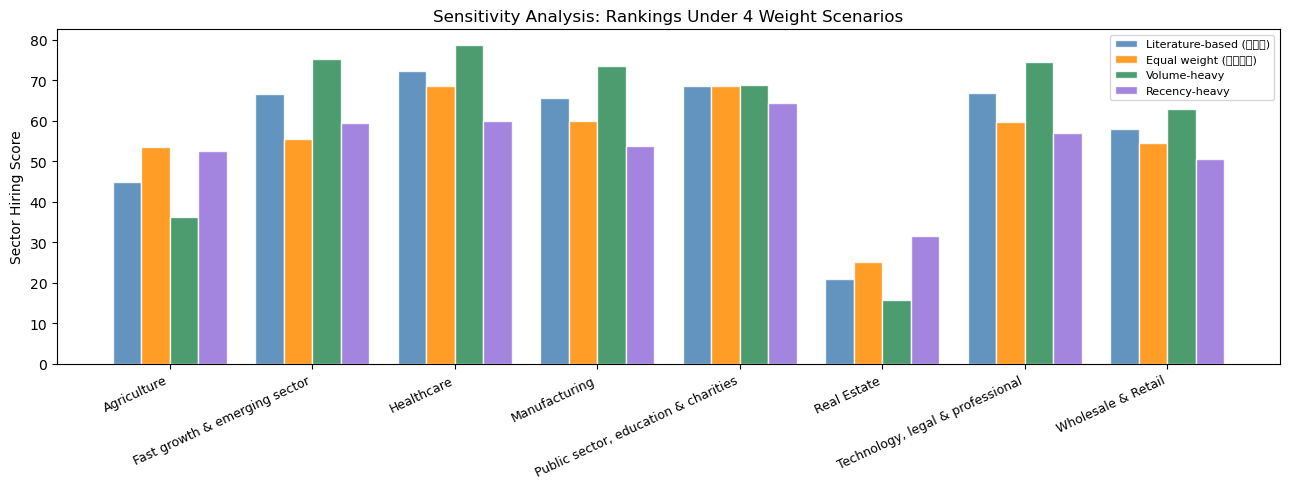

In [13]:
# =========================================================
# 敏感性分析：验证权重选择的稳健性
# =========================================================
# 对比4种权重方案下行业排名是否稳定
# 如果 Spearman 相关系数均 > 0.85，说明结论对权重选择不敏感
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

weight_scenarios = {
    "Literature-based (主方案)": [0.40, 0.25, 0.20, 0.15],
    "Equal weight (等权基准)":   [0.25, 0.25, 0.25, 0.25],
    "Volume-heavy":              [0.55, 0.20, 0.15, 0.10],
    "Recency-heavy":             [0.20, 0.50, 0.20, 0.10],
}

dims = ["volume_norm", "recency_norm", "coverage_norm", "breadth_norm"]

scores_df = pd.DataFrame({
    name: sum(w * sector_summary[d] for w, d in zip(weights, dims)) * 100
    for name, weights in weight_scenarios.items()
})
scores_df.index = sector_summary["sector"]

# Spearman 相关矩阵
print("=== Spearman 秩相关矩阵（> 0.85 说明排名稳定）===\n")
names = list(weight_scenarios.keys())
corr_rows = []
for s1 in names:
    row = {}
    for s2 in names:
        r, _ = spearmanr(scores_df[s1], scores_df[s2])
        row[s2] = round(r, 3)
    corr_rows.append(row)
corr_matrix = pd.DataFrame(corr_rows, index=names)
print(corr_matrix.to_string())

# 可视化
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(sector_summary))
width = 0.2
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

for i, (name, weights) in enumerate(weight_scenarios.items()):
    score = sum(w * sector_summary[d] for w, d in zip(weights, dims)) * 100
    ax.bar(x + i*width, score, width=width, label=name,
           color=colors[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(sector_summary["sector"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Sector Hiring Score")
ax.set_title("Sensitivity Analysis: Rankings Under 4 Weight Scenarios")
ax.legend(fontsize=8)
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "sensitivity_analysis.png", bbox_inches="tight", dpi=120)
plt.show()
# print(f"\n✓ 图表已保存 → {OUTPUT_DIR / 'sensitivity_analysis.png'}")


In [14]:
sector_raw

,sector,keyword,page,query_sector_keyword,contract_type,latitude,salary_max,adref,__CLASS__,description,...,desc_len,has_salary,salary_missing,location_depth,possible_agency_noise,generic_title_noise,keyword_in_title,keyword_in_desc,adzuna_total,contract_time
0,Manufacturing,manufacturing,1,Manufacturing::manufacturing,permanent,51.080127,49836.43,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc2MjcxNjkwMCIsI...,Adzuna::API::Response::Job,"Management Accountant - Manufacturing, Permane...",...,500,True,False,3,True,False,True,True,53539,NaN
1,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.757702,49556.15,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,"Financial Controller job, Manufacturing sector...",...,500,True,False,4,True,False,True,True,53539,NaN
2,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.480701,45532.82,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTcyNDgxNTI4MiIsI...,Adzuna::API::Response::Job,Work in a broad role in a growing business You...,...,500,True,False,4,True,True,True,True,53539,NaN
3,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.754200,51775.75,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,Job Title: Manufacturing Engineer – Electrical...,...,500,True,False,5,False,False,True,True,53539,NaN
4,Manufacturing,manufacturing,1,Manufacturing::manufacturing,NaN,53.758495,43891.34,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiMkxmYXZ4MXY4UkdGa...,Adzuna::API::Response::Job,Job Title: Manufacturing Engineer – Electrical...,...,500,True,False,5,False,False,True,True,53539,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3927,Fast growth & emerging sector,startup,2,Fast growth & emerging sector::startup,permanent,54.448101,30000.00,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiUUtEekNoNXY4Ukd3c...,Adzuna::API::Response::Job,Permanent Nightshift Production Operativerequi...,...,500,True,False,3,True,False,False,False,4037,NaN
3928,Fast growth & emerging sector,startup,2,Fast growth & emerging sector::startup,permanent,NaN,32280.03,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiUUtEekNoNXY4Ukd3c...,Adzuna::API::Response::Job,Your new company Join a growing and supportive...,...,500,True,False,1,True,False,False,True,4037,NaN
3929,Fast growth & emerging sector,startup,2,Fast growth & emerging sector::startup,permanent,NaN,100000.00,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiUUtEekNoNXY4Ukd3c...,Adzuna::API::Response::Job,"Software Engineer - Up to £160,000 - London Ti...",...,500,True,False,2,True,False,False,True,4037,NaN
3930,Fast growth & emerging sector,startup,2,Fast growth & emerging sector::startup,NaN,NaN,30000.00,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc2MTU1MTAxOSIsI...,Adzuna::API::Response::Job,Associate Recruitment Consultant | Belfast Cit...,...,500,True,False,3,False,False,False,True,4037,NaN


In [15]:
sector_raw.columns

Index(['sector', 'keyword', 'page', 'query_sector_keyword', 'contract_type',
       'latitude', 'salary_max', 'adref', '__CLASS__', 'description',
       'salary_is_predicted', 'longitude', 'redirect_url', 'salary_min', 'id',
       'created', 'title', 'category__label', 'category__tag',
       'category____CLASS__', 'location__area', 'location____CLASS__',
       'location__display_name', 'company__display_name', 'company____CLASS__',
       'company_display_name', 'location_display_name', 'location_area',
       'raw_item_json', 'title_len', 'desc_len', 'has_salary',
       'salary_missing', 'location_depth', 'possible_agency_noise',
       'generic_title_noise', 'keyword_in_title', 'keyword_in_desc',
       'adzuna_total', 'contract_time'],
      dtype='object')

In [16]:
# =========================================================
# Merge sector scores back to company table
# =========================================================
merge_cols = [
    "sector",
    "vacancy_count",
    "unique_jobs",
    "unique_titles",
    "unique_locations",
    "query_coverage",
    "latest_job_update",
    "days_since_latest",
    "sector_hiring_score",    # ← 进入 opportunity_score
    "noise_score",            # ← 附属质量字段，不进总分
    "hiring_signal_quality",  # ← 附属质量字段，不进总分
]

company_enriched = df.merge(
    sector_summary[merge_cols],
    left_on="primary_sector",
    right_on="sector",
    how="left"
)
company_enriched = company_enriched.drop(columns=["sector"])

# sector_hiring_score 作为 hiring_score 的别名，供后续 Opportunity Score notebook 直接用
company_enriched["hiring_score"] = company_enriched["sector_hiring_score"]

# 缺失的行业（如 Fast growth & emerging）填 0
company_enriched["hiring_score"]           = company_enriched["hiring_score"].fillna(0)
company_enriched["hiring_signal_quality"]  = company_enriched["hiring_signal_quality"].fillna(50)

print(f"公司主表合并完成：{len(company_enriched):,} 行")
print()
print("hiring_score 分布（各行业共享同一行业分）：")
print(
    company_enriched.groupby("primary_sector")[["hiring_score", "hiring_signal_quality"]]
    .first()
    .sort_values("hiring_score", ascending=False)
    .to_string()
)


公司主表合并完成：3,415,689 行

hiring_score 分布（各行业共享同一行业分）：
                                      hiring_score  hiring_signal_quality
primary_sector                                                           
Healthcare                                    72.4                   78.3
Public sector, education & charities          68.7                   89.7
Technology, legal & professional              66.9                   90.1
Fast growth & emerging sector                 66.7                   84.5
Manufacturing                                 65.7                   85.9
Wholesale & Retail                            58.0                   80.6
Agriculture                                   44.9                   84.5
Real Estate                                   20.8                   73.6


In [17]:
# =========================================================
# Export company-level output
# =========================================================
OUT_PATH = OUTPUT_DIR / "companies_with_sector_hiring.csv"

company_enriched.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print(f"  原始职位数据:  {RAW_JOBS_CSV}")
print(f"  行业汇总:      {SECTOR_SUMMARY_CSV}")
print(f"  公司主表输出:  {OUT_PATH}")
print()
print("关键字段说明：")
print("  hiring_score           → 进入 opportunity_score，权重 0.20")
print("  hiring_signal_quality  → 附属质量指标，不进总分")
print("                           高分 = Adzuna 数据干净，低分 = 噪声多")
print()
print("下一步：在 Opportunity Score notebook 中：")
print("  opportunity_score = (")
print("      0.50 * financial_score")
print("    + 0.30 * news_score")
print("    + 0.20 * hiring_score     ← 来自本文件")
print("  )")


  原始职位数据:  ../output/adzuna_sector_fullfield_output/adzuna_sector_jobs_raw_full.csv
  行业汇总:      ../output/adzuna_sector_fullfield_output/adzuna_sector_hiring_summary.csv
  公司主表输出:  ../output/adzuna_sector_fullfield_output/companies_with_sector_hiring.csv

关键字段说明：
  hiring_score           → 进入 opportunity_score，权重 0.20
  hiring_signal_quality  → 附属质量指标，不进总分
                           高分 = Adzuna 数据干净，低分 = 噪声多

下一步：在 Opportunity Score notebook 中：
  opportunity_score = (
      0.50 * financial_score
    + 0.30 * news_score
    + 0.20 * hiring_score     ← 来自本文件
  )


In [18]:
# =========================================================
# Optional full run
# =========================================================
# If the sample looks good, run on the full dataset:
#
# focus_companies_full = df[df["primary_sector"].isin(TARGET_SECTORS)].copy()
# sector_raw_full = run_sector_batch(SECTOR_QUERY_MAP, where=WHERE_VALUE)
# sector_summary_full = build_sector_hiring_summary(sector_raw_full)
# sector_summary_full.to_csv(SECTOR_SUMMARY_CSV, index=False, encoding="utf-8-sig")
# company_enriched_full = df.merge(
#     sector_summary_full[
#         [
#             "sector",
#             "vacancy_count",
#             "unique_jobs",
#             "unique_titles",
#             "unique_locations",
#             "query_coverage",
#             "latest_job_update",
#             "earliest_job_post",
#             "days_since_created",
#             "sector_hiring_score",
#             "noise_score",
#         ]
#     ],
#     left_on="primary_sector",
#     right_on="sector",
#     how="left"
# ).drop(columns=["sector"])
# company_enriched_full["hiring_score"] = company_enriched_full["sector_hiring_score"]
# company_enriched_full.to_csv(
#     OUTPUT_DIR / "companies_with_sector_hiring_full_payload_fullrun.csv",
#     index=False,
#     encoding="utf-8-sig"
# )


## Notes

- This notebook preserves the **full Adzuna raw payload** for each vacancy using `raw_item_json` and the flattened API fields.
- It also computes sector-level hiring and noise summaries so you can later build a more robust scoring model.
- The first run uses a sample size to validate the pipeline. Increase `SAMPLE_SIZE` or run the full block when ready.